In [1]:
import pandas as pd

annotations = pd.read_csv("annotations.csv")                #    истинные узлы (ground truth)
candidates = pd.read_csv("candidates_V2.csv")                  #    кандидаты (все подозрительные точки)
sample_submission = pd.read_csv("sampleSubmission.csv")     #    примеры ответов

print("annotations:", annotations.shape)
print("candidates:", candidates.shape)
print("sample_submission:", sample_submission.shape)

display(annotations.head())
display(candidates.head())
display(sample_submission.head())

annotations: (1186, 5)
candidates: (754975, 5)
sample_submission: (8, 5)


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


,seriesuid,coordX,coordY,coordZ,probability
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.6,-175.3,-298.3,1.0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.7,-211.9,-227.1,0.8
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.6,-140.9,876.3,0.2
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.0,192.1,-391.0,0.5
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.4,172.4,-405.4,1.0


In [2]:
 display(annotations.isna().sum())

seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64

In [3]:
display(candidates.isna().sum())

seriesuid    0
coordX       0
coordY       0
coordZ       0
class        0
dtype: int64

In [4]:
display(sample_submission.isna().sum())

seriesuid      0
coordX         0
coordY         0
coordZ         0
probability    0
dtype: int64

In [5]:
display(annotations.duplicated().sum())

np.int64(0)

In [6]:
display(candidates.duplicated().sum())

np.int64(0)

In [7]:
display(sample_submission.duplicated().sum())

np.int64(0)

In [8]:
display(candidates['class'].value_counts())

class
0    549714
1      1351
Name: count, dtype: int64

In [2]:
import SimpleITK as sitk
import numpy as np

def load_scan(path):
    itkimage = sitk.ReadImage(path)    # Читаем изображение КТ
    image = sitk.GetArrayFromImage(itkimage)    # Переводим ITK в нампай массив (z, y, x)
    spacing = itkimage.GetSpacing()    # Размер одного пикселя в мм (x, y, z)
    origin = itkimage.GetOrigin()    # Начало координат (в мм)
    return image, spacing, origin

In [3]:
image, spacing, origin = load_scan("/Users/aidungmas/Desktop/MFDP/Dataset/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.mhd")

print("shape:", image.shape)
print("spacing:", spacing)
print("origin", origin)

shape: (194, 512, 512)
spacing: (0.64453125, 0.64453125, 1.7999999523162842)
origin (-157.67773, -311.67773, -438.4)


In [4]:
# проверка превода координат узла в индексы массива
import numpy as np

row = annotations.iloc[0]
world_coord = np.array([row["coordX"], row["coordY"], row["coordZ"]])
spacing = np.array(spacing)
origin = np.array(origin)
voxel = np.round((world_coord - origin) / spacing).astype(int)
voxel = voxel[::-1]

print('world:', world_coord)
print('voxel:', voxel)

world: [-128.6994211 -175.3192718 -298.3875064]
voxel: [ 78 212  45]


In [5]:
# проверка внутри ли изображения
z, y, x = voxel

print("image shape:", image.shape)

print("z inside:", 0 <= z < image.shape[0])
print("y inside:", 0 <= y < image.shape[1])
print("x inside:", 0 <= x < image.shape[2])

image shape: (194, 512, 512)
z inside: True
y inside: True
x inside: True


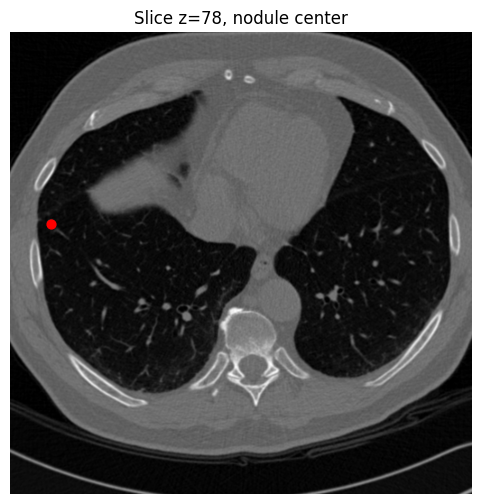

In [6]:
# смотрим где точка и отмечаем ее
import matplotlib.pyplot as plt

z, y, x = voxel

plt.figure(figsize=(6, 6))
plt.imshow(image[z], cmap="gray")
plt.scatter(x, y, c="red", s=40)
plt.title(f"Slice z={z}, nodule center")
plt.axis("off")
plt.show()

In [7]:
# размер патча (попробуем небольшой)
size = 32

z, y, x = voxel

patch = image[
    z - size//2 : z + size//2,
    y - size//2 : y + size//2,
    x - size//2 : x + size//2
]

print("patch shape:", patch.shape)

patch shape: (32, 32, 32)


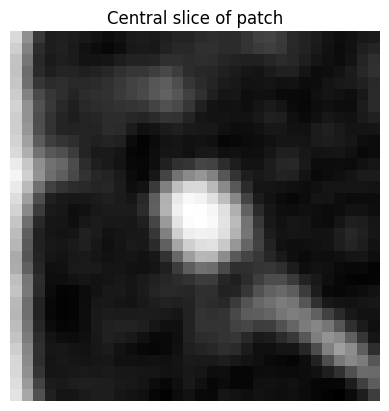

In [8]:
mid = size // 2

plt.imshow(patch[mid], cmap="gray")
plt.title("Central slice of patch")
plt.axis("off")
plt.show()

In [9]:
# функция для получения патча

def get_patch(image, voxel, size):
    z, y, x = voxel
    half = size // 2

    patch = np.zeros((size, size, size), dtype=image.dtype)

    z_min, z_max = z - half, z + half
    y_min, y_max = y - half, y + half
    x_min, x_max = x - half, x + half

    img_z_min = max(z_min, 0)
    img_z_max = min(z_max, image.shape[0])

    img_y_min = max(y_min, 0)
    img_y_max = min(y_max, image.shape[1])

    img_x_min = max(x_min, 0)
    img_x_max = min(x_max, image.shape[2])

    # Если центр настолько вне КТ, что реального пересечения нет — возвращаем пустой патч
    if img_z_min >= img_z_max or img_y_min >= img_y_max or img_x_min >= img_x_max:
        return patch

    patch_z_min = img_z_min - z_min
    patch_y_min = img_y_min - y_min
    patch_x_min = img_x_min - x_min

    patch_z_max = patch_z_min + (img_z_max - img_z_min)
    patch_y_max = patch_y_min + (img_y_max - img_y_min)
    patch_x_max = patch_x_min + (img_x_max - img_x_min)

    patch[
        patch_z_min:patch_z_max,
        patch_y_min:patch_y_max,
        patch_x_min:patch_x_max
    ] = image[
        img_z_min:img_z_max,
        img_y_min:img_y_max,
        img_x_min:img_x_max
    ]

    return patch

In [10]:
scan_id = "1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059"

scan_annotations = annotations[annotations["seriesuid"] == scan_id]

print("Количество узлов в этом КТ:", len(scan_annotations))
display(scan_annotations)

Количество узлов в этом КТ: 2


,seriesuid,coordX,coordY,coordZ,diameter_mm
25,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,46.188539,48.402806,-108.578632,13.596471
26,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,36.392044,76.771663,-123.321911,4.343200


In [11]:
patches = []

for _, row in scan_annotations.iterrows():
    world_coord = np.array([row["coordX"], row["coordY"], row["coordZ"]])
    voxel = np.round((world_coord - origin) / spacing).astype(int)
    voxel = voxel[::-1]
    
    patch = get_patch(image, voxel, size=32)

    if patch is not None:
        patches.append(patch)

print('Количество патчей:', len(patches))


Количество патчей: 2


In [13]:
scan_candidates = candidates[
    (candidates["seriesuid"] == scan_id) & 
    (candidates["class"] == 0)
]

negative_patches = []

for _,row in scan_candidates.iterrows():
    world_coord = np.array([row["coordX"], row["coordY"], row["coordZ"]])
    voxel = np.round((world_coord - origin) / spacing).astype(int)
    voxel = voxel[::-1]

    n_patches = get_patch(image, voxel, size=32)

    if n_patches is not None:
        negative_patches.append(n_patches)

print('Количество негативных патчей:', len(negative_patches))

Количество негативных патчей: 802


In [14]:
negative_patches_small = negative_patches[0:20:]

print(len(patches))
print(len(negative_patches_small))

2
20


In [19]:
X = np.array(patches + negative_patches_small)
X = np.expand_dims(X, axis=1)
y = np.array([1] * len(patches) + [0] * len(negative_patches_small))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22, 1, 32, 32, 32)
y shape: (22,)


In [20]:
import torch

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

print(X.shape)
print(y.shape)

torch.Size([22, 1, 32, 32, 32])
torch.Size([22])


In [21]:
from torch.utils.data import Dataset

class LungDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [22]:
dataset = LungDataset(X, y)

print(len(dataset))
print(dataset[0][0].shape)  # patch
print(dataset[0][1])        # label

22
torch.Size([1, 32, 32, 32])
tensor(1)


In [23]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [24]:
for batch_X, batch_y in loader:
    print("batch_X:", batch_X.shape)
    print("batch_y:", batch_y)
    break

batch_X: torch.Size([4, 1, 32, 32, 32])
batch_y: tensor([0, 0, 0, 0])


In [25]:
import torch.nn as nn
import torch.nn.functional as F

class Simple3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv3d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool3d(2)

        self.conv2 = nn.Conv3d(8, 16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(16 * 8 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32 → 16
        x = self.pool(F.relu(self.conv2(x)))   # 16 → 8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [26]:
model = Simple3DCNN()

for batch_X, batch_y in loader:
    outputs = model(batch_X)
    print("input:", batch_X.shape)
    print("output:", outputs.shape)
    print("labels:", batch_y.shape)
    break

input: torch.Size([4, 1, 32, 32, 32])
output: torch.Size([4, 2])
labels: torch.Size([4])


In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [28]:
for batch_X, batch_y in loader:
    
    optimizer.zero_grad()
    
    outputs = model(batch_X)
    
    loss = criterion(outputs, batch_y)
    
    loss.backward()
    optimizer.step()
    
    print("loss:", loss.item())
    
    break

loss: 0.5287102460861206


In [34]:
from sklearn.metrics import f1_score, fbeta_score, confusion_matrix

num_epochs = 5

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

        accuracy = correct / total

    print(f"Epoch {epoch+1}/{num_epochs}, loss: {total_loss:.4f}, acc: {accuracy:.2f}")

Epoch 1/5, loss: 2.3906, acc: 0.91
Epoch 2/5, loss: 1.7006, acc: 0.91
Epoch 3/5, loss: 1.7059, acc: 0.91
Epoch 4/5, loss: 1.6686, acc: 0.91
Epoch 5/5, loss: 1.6712, acc: 0.91


In [35]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

f1 = f1_score(all_true, all_preds)
f2 = fbeta_score(all_true, all_preds, beta=2)

tn, fp, fn, tp = confusion_matrix(all_true, all_preds).ravel()

fpr = fp / (fp + tn)

print("F1:", f1)
print("F2:", f2)
print("FPR:", fpr)

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

F1: 0.0
F2: 0.0
FPR: 0.0
TN: 20
FP: 0
FN: 2
TP: 0
